<a href="https://colab.research.google.com/github/gauritiwari08-sudo/Data-Analyst-Portfolio/blob/main/Python/CapstoneProject_MArketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd drive/MyDrive

/content/drive/MyDrive


In [ ]:
# loading all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# reading the files
data = pd.read_excel('data.xlsx')
country = pd.read_excel('Country-Code.xlsx')

# display the first 5 rows
data.head()

# displaying no of rows and columns
data.shape

# displaying no of rows and columns
country.shape

df=pd.merge(data,country,on="Country Code",how="left")

# displaying the basic summary of the data
df.info()

# display the statistics of numerical col
df.describe()
# displaying the statistics of object column
df.describe(include='object')

# checking for missing values
df.isnull().sum()
# checking for duplicates
df.duplicated().sum()










<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9550 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Price range           9551 non-null   int64  
 15  Aggregate rating     

np.int64(0)

In [70]:
df

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes,Country,Cuisine_Count,no_cuisines
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,2,...,No,No,3,4.1,Green,Very Good,1498,Indonesia,1,1
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,3,...,No,No,3,4.6,Dark Green,Excellent,873,Indonesia,1,1
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,2,...,No,No,3,4.9,Dark Green,Excellent,605,Indonesia,1,1
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,1,...,No,No,3,4.2,Green,Very Good,395,Indonesia,1,1
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,2,...,No,No,3,4.3,Green,Very Good,243,Indonesia,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,18279289,BMG - All Day Dining,1,Dehradun,"140 A, Rajpur Road, Jakhan, Dehradun",Jakhan,"Jakhan, Dehradun",78.068890,30.362686,3,...,No,No,1,4.3,Green,Very Good,63,India,1,1
9547,2300497,Atmosphere Grill Cafe Sheesha,1,Kanpur,"8th Floor, J.S. Tower, 16/106 - Mall Road, Kan...",Mall Road,"Mall Road, Kanpur",80.354002,26.472001,3,...,No,No,1,3.6,Yellow,Good,34,India,1,1
9548,18312106,UrbanCrave,1,Kanpur,"14/125, The Mall, Mall Road, Colonelganj, Para...",Parade,"Parade, Kanpur",80.342796,26.474986,6,...,No,No,1,3.9,Yellow,Good,127,India,1,1
9549,3900245,Deena Chat Bhandar,1,Varanasi,"D-47/184, Luxa Road, Dashaswmedh Road, Varanasi",Dashaswmedh Road,"Dashaswmedh Road, Varanasi",0.000000,0.000000,1,...,No,No,1,3.8,Yellow,Good,78,India,1,1


In [ ]:
# no of restaurants in the cities
city_count = df['City'].value_counts()
city_count

,count
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25
...,...
Vernonia,1
Dicky Beach,1
Inverloch,1


In [ ]:

# city with max restaurants
city_count.head(1)

,count
City,
New Delhi,5473


In [ ]:

# city with min restaurants
city_count.tail(1)

,count
City,
Miller,1


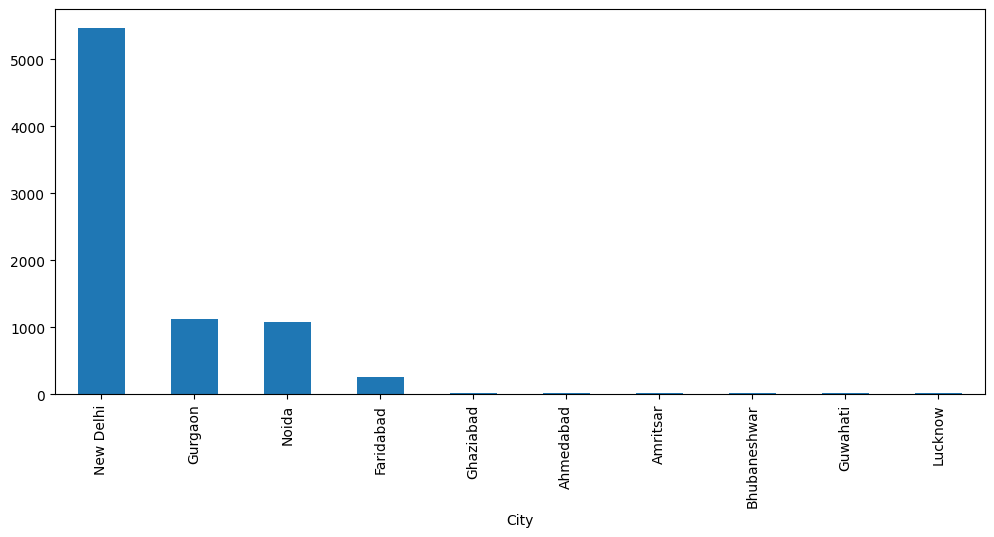

In [ ]:
# Explore the geographical distribution of the restaurants
# and identify the cities with the maximum and minimum number of restaurants
plt.figure(figsize=(12,5))
city_count.head(10).plot(kind='bar')
plt.show()

In [ ]:
#Restaurant franchising is a thriving venture.
#So, it is very important to explore the franchise with most national presence

franchise = (df.groupby('Restaurant Name')['City'].nunique().sort_values(ascending=False))
franchise

,City
Restaurant Name,
Barbeque Nation,22
Pizza Hut,12
KFC,8
The Yellow Chilli,7
Domino's Pizza,7
...,...
Fu.D,1
Fry Centre,1
Fruitpro,1


In [ ]:
# Find out the ratio between restaurants that allow table booking vs.
# those that do not allow table booking
table_booking = df['Has Table booking'].value_counts()
print(table_booking)


Has Table booking
No     8393
Yes    1158
Name: count, dtype: int64


In [ ]:

ratio = table_booking['Yes']/table_booking['No']
print(ratio)


0.13797211962349576


In [ ]:

# Find out the percentage of restaurants providing online delivery
online_delivery= (df['Has Online delivery']=='Yes').sum()
print(online_delivery)
percentage_online_delivery = (online_delivery/len(df))*100
print(percentage_online_delivery)




2451
25.662234321013504


In [ ]:
len(df)

9551

In [ ]:

votes = df.groupby("Has Online delivery")["Votes"].sum()
print(votes)


Has Online delivery
No     980731
Yes    517914
Name: Votes, dtype: int64


In [ ]:
#Calculate the difference
#in number of votes for the restaurants that deliver and the restaurants that do not deliver
difference = abs(votes['Yes']-votes['No'])
print(difference)


462817


In [ ]:

cuisine = df.copy()
cuisine['Cuisines']=cuisine['Cuisines'].fillna("Unknown")


In [ ]:
cuisine['Cuisines'].isna().sum()

np.int64(0)

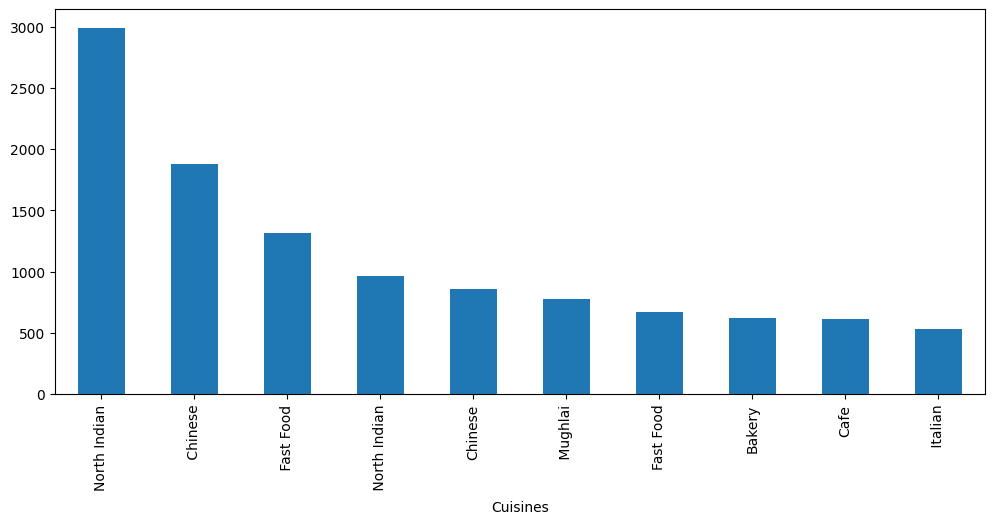

In [ ]:
cuisine = cuisine.assign(Cuisines=cuisine['Cuisines'].str.split(","))
cuisine
cuisine = cuisine.explode('Cuisines')
top10 = cuisine['Cuisines'].value_counts().head(10)
top10
plt.figure(figsize=(12,5))
top10.plot(kind='bar')
plt.show()



In [ ]:
print(df['Cuisines'].isna().sum())

9


In [ ]:
#df['Cuisines'].fillna("").apply(lambda x:len(x.split(",")))
df['Cuisines'].max()


8

In [ ]:
df['Cuisines'].min()

1

In [ ]:
#What are the top 10 cuisines served across cities?
city_cuisine = cuisine.groupby(['City','Cuisines']).size().reset_index(name='Count')
city_cuisine.sort_values(by='Count',ascending=False).head(10)


,City,Cuisines,Count
1621,New Delhi,North Indian,1848
1516,New Delhi,Chinese,1069
1521,New Delhi,Fast Food,858
1553,New Delhi,North Indian,577
1588,New Delhi,Chinese,569
1549,New Delhi,Mughlai,467
1594,New Delhi,Fast Food,446
1711,Noida,North Indian,433
1579,New Delhi,Bakery,397
994,Gurgaon,North Indian,367


In [ ]:
#What is the maximum and minimum number of cuisines that a restaurant serves?
df['Cuisine_Count'] = df['Cuisines'].astype(str).fillna('').apply(lambda x: len(x.split(',')) if x else 0)

max_cuisines = df['Cuisine_Count'].max()
min_cuisines = df['Cuisine_Count'].min()

print(f"Maximum number of cuisines a restaurant serves: {max_cuisines}")
print(f"Minimum number of cuisines a restaurant serves: {min_cuisines}")

Maximum number of cuisines a restaurant serves: 1
Minimum number of cuisines a restaurant serves: 1


In [ ]:
# which is the most served cuisine across the restaurant for each city?
most_served_cuisine_per_city = city_cuisine.loc[city_cuisine.groupby('City')['Count'].idxmax()]
display(most_served_cuisine_per_city)

,City,Cuisines,Count
24,Abu Dhabi,Indian,6
45,Agra,North Indian,12
55,Ahmedabad,Continental,9
91,Albany,American,4
123,Allahabad,North Indian,10
...,...,...,...
2365,Weirton,Greek,1
2378,Wellington City,Cafe,6
2388,Winchester Bay,Seafood,1
2391,Yorkton,Asian,1


In [ ]:
# What is the distribution cost across the restaurants?
df['Average Cost for two']

,Average Cost for two
0,800000
1,800000
2,500000
3,450000
4,350000
...,...
9546,0
9547,0
9548,0
9549,0


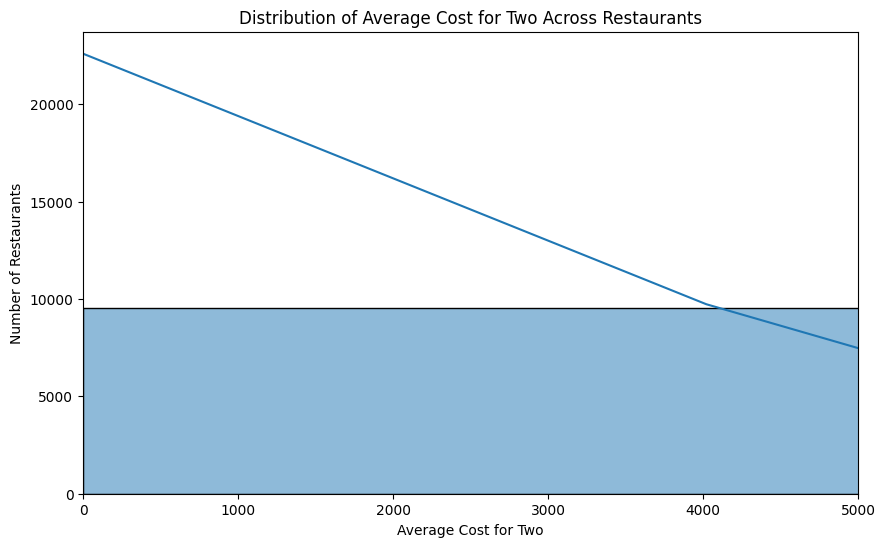

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Average Cost for two'], bins=50, kde=True)
plt.title('Distribution of Average Cost for Two Across Restaurants')
plt.xlabel('Average Cost for Two')
plt.ylabel('Number of Restaurants')
plt.xlim(0, 5000) # Limiting x-axis for better visualization, as some costs can be very high
plt.show()



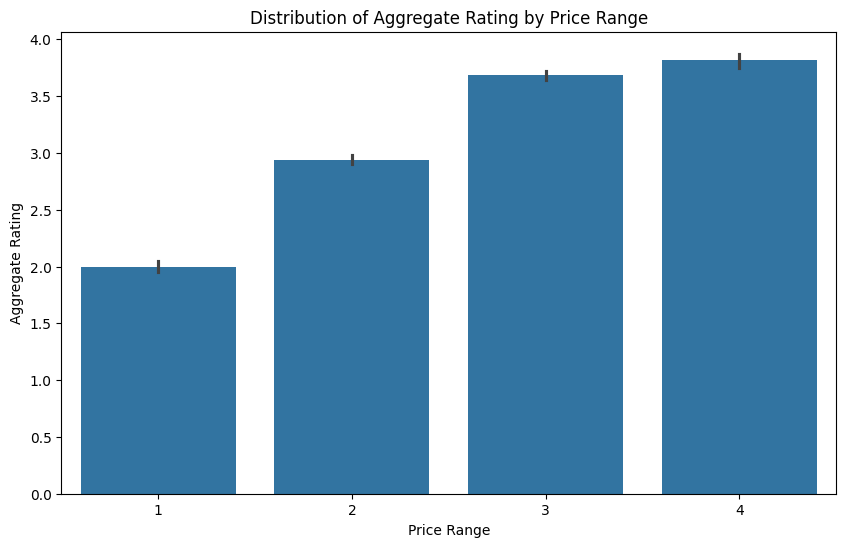

In [66]:
#How ratings are distributed among the various factors?
plt.figure(figsize=(10, 6))
#plot(x='Price range', y='Aggregate rating', data=df)
sns.barplot(x='Price range', y='Aggregate rating', data=df)
plt.title('Distribution of Aggregate Rating by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Aggregate Rating')
plt.show()

In [71]:
# Visualize the variables using Tableau to help user explore the data
# and create a better understanding of the restaurants to identify the "star" restaurant
df

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes,Country,Cuisine_Count,no_cuisines
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,2,...,No,No,3,4.1,Green,Very Good,1498,Indonesia,1,1
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,3,...,No,No,3,4.6,Dark Green,Excellent,873,Indonesia,1,1
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,2,...,No,No,3,4.9,Dark Green,Excellent,605,Indonesia,1,1
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,1,...,No,No,3,4.2,Green,Very Good,395,Indonesia,1,1
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,2,...,No,No,3,4.3,Green,Very Good,243,Indonesia,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,18279289,BMG - All Day Dining,1,Dehradun,"140 A, Rajpur Road, Jakhan, Dehradun",Jakhan,"Jakhan, Dehradun",78.068890,30.362686,3,...,No,No,1,4.3,Green,Very Good,63,India,1,1
9547,2300497,Atmosphere Grill Cafe Sheesha,1,Kanpur,"8th Floor, J.S. Tower, 16/106 - Mall Road, Kan...",Mall Road,"Mall Road, Kanpur",80.354002,26.472001,3,...,No,No,1,3.6,Yellow,Good,34,India,1,1
9548,18312106,UrbanCrave,1,Kanpur,"14/125, The Mall, Mall Road, Colonelganj, Para...",Parade,"Parade, Kanpur",80.342796,26.474986,6,...,No,No,1,3.9,Yellow,Good,127,India,1,1
9549,3900245,Deena Chat Bhandar,1,Varanasi,"D-47/184, Luxa Road, Dashaswmedh Road, Varanasi",Dashaswmedh Road,"Dashaswmedh Road, Varanasi",0.000000,0.000000,1,...,No,No,1,3.8,Yellow,Good,78,India,1,1


In [67]:
df.to_csv('restaurant_data.csv', index=False)
print('DataFrame exported to restaurant_data.csv in Google Drive.')


DataFrame exported to restaurant_data.csv in Google Drive.


In [68]:
df.to_excel('restaurant_data.xlsx', index=False)
print('DataFrame exported to restaurant_data.xlsx in Google Drive.')

DataFrame exported to restaurant_data.xlsx in Google Drive.
